# Модель для предсказания вероятности клика (CTR) на рекламное объявление

### Постановка задачи машинного обучения <a id='Постановка-задачи-машинного-обучения'></a>

**Тип задачи:** Бинарная классификация.

**Цель:** Построить модель, предсказывающую вероятность клика (CTR - Click-Through Rate, «коэффициент кликабельности») на рекламное объявление, для AdTech-платформы "Advandex". Важно, чтобы предсказанные вероятности кликов максимально точно соответствовали их реальной частоте, т.е. необходимо добиться высокой калибровки предсказаний. Это критично для эффективного управления бюджетом рекламодателей и максимизации дохода платформы.

**Объект:** Событие показа рекламы (каждая строка в датасете — один уникальный показ баннера).

**Признаки (features):** Набор характеристик показа.

**Целевая переменная (target):** бинарный флаг клика:

- `0` — «Клик не произошел»;
- `1` — «Клик выполнен».

**Модель:** В качестве базовых моделей используются логистическая регрессия и метод опорных векторов с линейным ядром. Основное внимание уделяется интерпретируемости и калибровке вероятностей (с помощью изотонической регрессии). Для подбора гиперпараметров применяется `GridSearchCV`, а в качестве базовой модели — `DummyClassifier`.

**Метрики оценки:**

- `PR-AUC` (Precision-Recall AUC) — основная метрика для несбалансированных данных, фокусируется на качестве предсказаний для класса кликов;
- `Log Loss` — оценивает точность предсказанных вероятностей, важна для оптимизации ставок на аукционах;
- `Brier Score` — измеряет калибровку и точность прогнозов;
- дополнительные метрики: 
    - `ECE` (Expected Calibration Error) - средняя ошибка калибровки вероятностей по диапазонам, 
    - `MCE` (Maximum Calibration Error) - максимальная ошибка калибровки среди всех диапазонов, 
    - `Precision` - точность предсказания кликов (доля верно предсказанных кликов среди всех, кого модель отметила как «клик»), 
    - `Recall` - полнота охвата реальных кликов (доля верно предсказанных кликов от всех реальных кликов), 
    - `F1-score` - балансирует точность и полноту, гармоническое среднее между Precision и Recall.


**Ограничения и требования:**

- Обеспечение воспроизводимости результатов (фиксация `random_state`);
- обработка пропусков и категориальных признаков с использованием кросс-валидации;
- сохранение полного пайплайна (модель + предобработка) с помощью `pickle/joblib` для внедрения;
- особое внимание к калибровке вероятностей.

**Ожидаемый результат:** Обученная и откалиброванная модель, которая на новых данных выдаёт достоверную вероятность клика для каждого показа. Это позволит платформе эффективно управлять аукционами, оптимизировать расходы рекламодателей и максимизировать доход, минимизируя финансовые риски.

### Описание данных <a id='Описание-данных'></a>

Данные, представленные в файле `ds_s16_ad_click_dataset.csv`, содержат данные из из систем показа рекламы и логирования взаимодействий пользователей с рекламными баннерами. Датасет содержит следующие признаки:

Идентификаторы и временные метки:
- `id` — уникальный идентификатор записи о показе баннера;
- `hour` — час, в который был показан баннер, в формате 'YYMMDDHH'.

Характеристики рекламной площадки (Site):
- `site_id` — идентификатор веб-сайта, на котором был показан баннер;
- `site_domain` — домен веб-сайта;
- `site_category` — тематическая категория веб-сайта.

Характеристики рекламируемого приложения (App):
- `app_id` — идентификатор рекламируемого мобильного приложения;
- `app_domain` — домен рекламируемого приложения;
- `app_category` — категория рекламируемого приложения.

Характеристики устройства и соединения пользователя:
- `device_id` — идентификатор браузера или устройства;
- `device_ip` — IP-адрес устройства;
- `device_model` — модель устройства пользователя;
- `device_type` — тип устройства пользователя: например, смартфон, планшет, ПК;
- `device_conn_type` — тип сетевого соединения устройства: например, Wi-Fi, 3G, 4G.

Характеристики рекламного баннера и аукциона:
- `C1` — анонимизированный признак, характеризующий контекст показа;
- `banner_pos` — позиция баннера на веб-странице;
- `C14`-`C21` — группа анонимизированных признаков, описывающих параметры баннера, пользователя или аукциона.

Машинно-сгенерированные признаки (ML Features):
- `ml_feature_1`, `ml_feature_3`-`ml_feature_6`, `ml_feature_8`-`ml_feature_10` — числовые признаки, полученные в результате предварительной обработки и генерации новых признаков;
- `ml_feature_2`, `ml_feature_7` — категориальные признаки, полученные в результате предварительной обработки и генерации новых признаков.

Целевая переменная:
- `click` — бинарный признак, указывающий, был ли совершён клик по баннеру. 1 — клик был, 0 — клика не было.

### Содержание проекта

[1. Подготовка среды и загрузка данных](#Подготовка-среды-и-загрузка-данных)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[1.1 Подготовка библиотек](#Подготовка-библиотек)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[1.2 Константа для воспроизводимости](#Константа-для-воспроизводимости)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[1.3 Загрузка данных](#Загрузка-данных)<br>
[2. Исследовательский анализ данных (EDA)](#Исследовательский-анализ-данных)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[2.1 Базовая информация о датасете](#Базовая-информация-о-датасете)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[2.2 Анализ целевой переменной](#Анализ-целевой-переменной)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[2.3 Анализ признаков](#Анализ-признаков)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[2.4 Анализ пропущенных значений](#Анализ-пропущенных-значений)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[2.5 Анализ категориальных признаков](#Анализ-категориальных-признаков)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[2.6 Анализ выбросов и распределений](#Анализ-выбросов-и-распределений)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[2.7 Корреляции](#Корреляции)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[2.8 Выводы по EDA](#Выводы-по-EDA)<br>
[3. Разделение данных на выборки](#Разделение-данных-на-выборки)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[3.1 Разделение данных](#Разделение-данных)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[3.2 Проверка разделения данных](#Проверка-разделения-данных)<br>
[4. Предобработка данных](#Предобработка-данных)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[4.1 Создание пайплайнов для предобработки данных](#Создание-пайплайнов-для-предобработки-данных)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[4.2 Объединение пайплайнов](#Объединение-пайплайнов)<br>
[5. Отбор признаков](#Отбор-признаков)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[5.1 Фильтрационные методы](#Фильтрационные-методы)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[5.2 Методы-обёртки](#Методы-обёртки)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[5.3 Финальный набор признаков](#Финальный-набор-признаков)<br>
[6. Обучение базовой модели](#Обучение-базовой-модели)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[6.1 DummyClassifier](#DummyClassifier)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[6.2 LogisticRegression](#LogisticRegression)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[6.3 SVC](#SVC)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[6.4 Сравнение моделей](#Сравнение-моделей)<br>
[7. Подбор гиперпараметров](#Подбор-гиперпараметров)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[7.1 Сетка гиперпараметров](#Сетка-гиперпараметров)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[7.2 Grid Search  с кросс-валидацией](#Grid-Search-с-кросс-валидацией)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[7.3 Анализ результатов](#Анализ-результатов)<br>
[8. Финальная модель](#Финальная-модель)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[8.1 Обучение финальной модели](#Обучение-финальной-модели)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[8.2 Метрики на тестовой выборке](#Метрики-на-тестовой-выборке)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[8.3 Веса модели](#Веса-модели)<br>
[9. Калибровка модели](#Калибровка-модели)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[9.1 Текущая калибровка](#Текущая-калибровка)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[9.2 Применение методов калибровки](#Применение-методов-калибровки)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[9.3 Сравнение моделей до и после калибровки](#Сравнение-моделей-до-и-после-калибровки)<br>
[10. Оценка качества калибровки](#Оценка-качества-калибровки)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[10.1 Метрики калибровки](#Метрики-калибровки)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[10.2 Сравнение моделей до и после калибровки](#Сравнение-моделей-до-и-после-калибровки-2)<br>
[11. Финальный отчёт и выводы](#Финальный-отчёт-и-выводы)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[11.1 Сравнительный анализ моделей и метрик](#Сравнительный-анализ-моделей-и-метрик)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[11.2 Ключевые выводы](#Ключевые-выводы)<br>
[12. Сохранение модели для продакшена](#Сохранение-модели-для-продакшена)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[12.1 Сохранение артефактов](#Сохранение-артефактов)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[12.2 Проверка работоспособности кода](#Проверка-работоспособности-кода)

## 1. Подготовка среды и загрузка данных <a id='Подготовка-среды-и-загрузка-данных'></a>

#### 1.1 Подготовка библиотек <a id='Подготовка-библиотек'></a>

In [1]:
# pip install -r requirements.txt

# !pip install phik -q

In [2]:
# Работа с данными и визуализация
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn
import sys
# Анализ корреляций в данных
import phik
from phik import phik_matrix

# Моделирование и оценка
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, log_loss, brier_score_loss
# Модели
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
# Отбор признаков
from sklearn.feature_selection import VarianceThreshold, RFE

# Пайплайны и предобработка
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from category_encoders import TargetEncoder
from sklearn.impute import SimpleImputer
# Калибровка вероятностей
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# Сохранение модели
import joblib

In [3]:
print('✅ Библиотеки успешно импортированы.')
print(f'Pandas версия: {pd.__version__}')
print(f'NumPy версия: {np.__version__}')
print(f'Matplotlib версия: {matplotlib.__version__}')
print(f'Seaborn версия: {sns.__version__ }')
print(f'Scikit-learn версия: {sklearn.__version__}')
print(f'Phik версия: {phik.__version__}')
print(f'Joblib версия: {joblib.__version__}')
print(f'Python версия: {sys.version.split()[0]}')

✅ Библиотеки успешно импортированы.
Pandas версия: 1.3.4
NumPy версия: 1.20.3
Matplotlib версия: 3.4.3
Seaborn версия: 0.11.2
Scikit-learn версия: 0.24.2
Phik версия: 0.12.5
Joblib версия: 1.1.0
Python версия: 3.9.7


#### 1.2 Константа для воспроизводимости <a id='Константа-для-воспроизводимости'></a>

Для обеспечения воспроизводимости экспериментов в коде зададим константу `random_seed`. Эта константа используется для инициализации генераторов случайных чисел во всех библиотеках, участвующих в проекте.

In [4]:
# Зафиксируем random_state для воспроизводимости результатов
RANDOM_STATE = 42

#### 1.3 Загрузка данных <a id='Загрузка-данных'></a>

Загрузим датасет из CSV-файла с помощью соответствующей функции библиотеки pandas.

После загрузки выведем на экран информацию о загруженном датасете: его размер и информацию о типах столбцов, а также отобразим первые несколько строк для ознакомления со структурой. Это позволит быстро оценить корректность загрузки и выявить возможные проблемы с типами или пропущенными значениями.

In [5]:
# Загрузим данные из CSV-файла (сепаратор ",", для чтения чисел с плавающей точкой decimal=".")
df = pd.read_csv('/datasets/ds_s16_ad_click_dataset.csv', sep=',', decimal='.')
print('✅ Данные успешно загружены.')

✅ Данные успешно загружены.


In [6]:
# Выведем размер датасета: общее количество строк и признаков
total_rows = df.shape[0]
total_columns = df.shape[1]
print(f'Общее количество строк: {total_rows}.')
print(f'Общее количество признаков: {total_columns}.')

Общее количество строк: 50000.
Общее количество признаков: 34.


In [7]:
# Выведем наименование признаков
df.columns

Index(['id', 'click', 'hour', 'C1', 'banner_pos', 'site_id', 'site_domain',
       'site_category', 'app_id', 'app_domain', 'app_category', 'device_id',
       'device_ip', 'device_model', 'device_type', 'device_conn_type', 'C14',
       'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1',
       'ml_feature_2', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5',
       'ml_feature_6', 'ml_feature_7', 'ml_feature_8', 'ml_feature_9',
       'ml_feature_10'],
      dtype='object')

Для удобства анализа и моделирования переупорядочим столбцы, сгруппировав их в соответствии с блоками, описание которых приведено в пункте "[Описание данных](#Описание-данных)", а также приведем имена всех столбцов к нижнему регистру.

In [8]:
# Новый порядок столбцов и приведение к нижнему регистру
df = df[['id', 'hour', 
         'site_id', 'site_domain', 'site_category', 
         'app_id', 'app_domain', 'app_category', 
         'device_id', 'device_ip', 'device_model', 'device_type', 'device_conn_type', 
         'banner_pos', 'C1', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 
         'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 
         'ml_feature_10', 'ml_feature_2', 'ml_feature_7', 
         'click']].rename(columns=str.lower)

Оптимизируем типы данных для экономии оперативной памяти и ускорения обработки данных.

In [9]:
def classify_columns(df):
    '''
    Классифицирует столбцы датафрейма на числовые, категориальные и бинарные.
    '''
    numerical_features = df.select_dtypes(include='number').columns.tolist()
    categorical_features = df.select_dtypes(include=['object']).columns.tolist()

    binary_features = []
    
    # Проверка числовых столбцов на бинарность
    for column in numerical_features:
        unique_vals = sorted(df[column].dropna().unique())
        if unique_vals == [0, 1] or unique_vals == [0.0, 1.0]:
            binary_features.append(column)
            
    # Проверка категориальных столбцов на бинарность
    for column in categorical_features:
        if len(df[column].dropna().unique()) == 2:
            binary_features.append(column)
            
    # Исключение бинарных столбцов из числовых и категориальных
    numerical_features = [col for col in numerical_features if col not in binary_features]
    categorical_features = [col for col in categorical_features if col not in binary_features]
    
    return {
        'numerical': numerical_features,
        'categorical': categorical_features,
        'binary': binary_features
    }

In [10]:
# Получаем классификацию
column_types = classify_columns(df)

# Оптимизируем целочисленный тип данных в датафрейме
int_columns = [col for col in column_types['numerical'] if pd.api.types.is_integer_dtype(df[col])]
for column in int_columns:
    df[column] = pd.to_numeric(df[column], downcast='integer')

# Оптимизируем числовой тип данных с плавающей точкой в датафрейме
float_columns = [col for col in column_types['numerical'] if pd.api.types.is_float_dtype(df[col])]
for column in float_columns:
    df[column] = pd.to_numeric(df[column], downcast='float')

In [11]:
# Выведем информацию о датафрейме и его первые строки
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float32
 1   hour              50000 non-null  int32  
 2   site_id           50000 non-null  object 
 3   site_domain       50000 non-null  object 
 4   site_category     50000 non-null  object 
 5   app_id            50000 non-null  object 
 6   app_domain        50000 non-null  object 
 7   app_category      50000 non-null  object 
 8   device_id         50000 non-null  object 
 9   device_ip         50000 non-null  object 
 10  device_model      50000 non-null  object 
 11  device_type       50000 non-null  int8   
 12  device_conn_type  50000 non-null  int8   
 13  banner_pos        50000 non-null  int8   
 14  c1                50000 non-null  int16  
 15  c14               50000 non-null  int16  
 16  c15               50000 non-null  int16 

,id,hour,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,...,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10,ml_feature_2,ml_feature_7,click
0,1.005263e+19,14102100,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,488a9a3e,...,0.666588,0,0.817292,0.993275,-0.619959,0.433666,0.274038,A,Z,1
1,1.010597e+19,14102100,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,75bb1b58,...,5.146790,1,-0.883865,-0.825722,0.576526,-0.318558,-0.132851,C,X,0
2,1.012048e+19,14102100,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,285263b0,...,7.169348,0,-0.859440,-0.338365,-0.440047,-0.345412,0.340487,D,Y,0
3,1.021995e+18,14102100,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,0f2161f8,a99f214a,18190986,...,-0.290708,1,0.062795,0.062934,0.551982,0.733382,-0.198542,A,Y,0
4,1.023455e+19,14102100,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,b66e5482,...,6.319133,1,-0.675276,0.797144,0.640827,0.297955,-0.136909,A,X,0


In [12]:
# Зафиксируем наименование признаков до изменений
original_columns = df.columns.tolist()

## 2. Исследовательский анализ данных (EDA) <a id='Исследовательский-анализ-данных'></a>

#### 2.1 Базовая информация о датасете <a id='Базовая-информация-о-датасете'></a>

Датасет `ds_s16_ad_click_dataset.csv` содержит 34 столбца (признака) и 50000 строк, каждая из которых — это один уникальный показ баннера.

После первичного анализа данных можно сделать следующие выводы:

- названия всех столбцов приведены к одному виду и отражают содержимое;
- во всех столбцах тип данных соответствует содержимому; 
- тип данных числовых столбцов оптимизирован;
- пропуски в данных отсутствуют.

In [13]:
print('\nКЛАССИФИКАЦИЯ ПРИЗНАКОВ ПО ТИПАМ ДАННЫХ:')
print('\nЧисловые признаки:')
for i, col in enumerate(column_types['numerical'], 1):
    print(f"  {i}. {col}")

print('\nКатегориальные признаки:')
for i, col in enumerate(column_types['categorical'], 1):
    print(f"  {i}. {col}")

print('\nБинарные признаки:')
for i, col in enumerate(column_types['binary'], 1):
    print(f"  {i}. {col}")

print(f'\nИтого датасет содержит {len(column_types["numerical"])} числовой, {len(column_types["categorical"])} категориальных и {len(column_types["binary"])} бинарных признаков.')


КЛАССИФИКАЦИЯ ПРИЗНАКОВ ПО ТИПАМ ДАННЫХ:

Числовые признаки:
  1. id
  2. hour
  3. device_type
  4. device_conn_type
  5. banner_pos
  6. c1
  7. c14
  8. c15
  9. c16
  10. c17
  11. c18
  12. c19
  13. c20
  14. c21
  15. ml_feature_1
  16. ml_feature_3
  17. ml_feature_5
  18. ml_feature_6
  19. ml_feature_8
  20. ml_feature_9
  21. ml_feature_10

Категориальные признаки:
  1. site_id
  2. site_domain
  3. site_category
  4. app_id
  5. app_domain
  6. app_category
  7. device_id
  8. device_ip
  9. device_model
  10. ml_feature_2
  11. ml_feature_7

Бинарные признаки:
  1. ml_feature_4
  2. click

Итого датасет содержит 21 числовой, 11 категориальных и 2 бинарных признаков.


Получим сводную статистику по всем столбцам датасета, что позволит быстро оценить распределение данных, выявить аномалии и понять структуру датасета.

In [14]:
df.describe(include='all')

,id,hour,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,...,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10,ml_feature_2,ml_feature_7,click
count,5.000000e+04,5.000000e+04,50000,50000,50000,50000,50000,50000,50000,50000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000,50000,50000.000000
unique,NaN,NaN,1160,1013,18,976,67,22,8580,41455,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,3,NaN
top,NaN,NaN,85f751fd,c4e18dd6,50e219e0,ecad2386,7801e8d9,07d7df22,a99f214a,6b9769f2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E,Y,NaN
freq,NaN,NaN,18011,18645,20457,31989,33763,32388,41213,265,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10112,17081,NaN
mean,9.215430e+18,1.410256e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.036381,0.498040,0.034729,0.022948,0.025465,0.035361,0.020226,NaN,NaN,0.172060
std,5.328516e+18,2.967892e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.792316,0.500001,1.002114,0.656690,0.578024,0.505033,0.303307,NaN,NaN,0.377436
min,3.191077e+13,1.410210e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-9.999742,0.000000,-4.631853,-1.000000,-0.999965,-2.147526,-1.287965,NaN,NaN,0.000000
25%,4.580649e+18,1.410230e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-5.059555,0.000000,-0.639829,-0.579775,-0.470627,-0.304077,-0.182386,NaN,NaN,0.000000
50%,9.243015e+18,1.410260e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.056155,0.000000,0.028112,0.037786,0.027348,0.035985,0.018930,NaN,NaN,0.000000
75%,1.380920e+19,1.410281e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.985939,1.000000,0.707594,0.637131,0.521117,0.374152,0.224080,NaN,NaN,0.000000


Предварительный анализ описательной статистики позволяет сделать следующие выводы о структуре и качестве данных:
- данные содержат как числовые, так и категориальные признаки, что требует применения соответствующих методов предобработки;
- в данных присутствуют признаки с экстремально высокой кардинальностью ('device_ip', 'device_id'), использование которых может привести к переобучению;
- набор данных характеризуется значительной несбалансированностью целевой переменной 'click' (доля положительного класса составляет всего 17.21%), что требует внимания при выборе метрик качества модели.

In [15]:
# Проверим датафрем на наличие полных дубликатов
explicit_duplicate_count = df.duplicated().sum()

if explicit_duplicate_count > 0:
    print(f'Количество явных дубликатов в датафрейме: {explicit_duplicate_count}.')
else:
    print('Явные дубликаты в датасете отсутствуют.')

Явные дубликаты в датасете отсутствуют.


#### 2.2 Анализ целевой переменной <a id='Анализ-целевой-переменной'></a>

Целевая переменная является бинарной и показывает, был ли совершён клик по баннеру или нет:

- `0` — «Нет клика»;
- `1` — «Есть клик».

Проанализируем распределение целевой переменной.

In [16]:
def analyze_column_balance(df, column_name):
    '''
    Анализирует баланс классов в указанном столбце датафрейма.
    Параметры:  
        df (pd.DataFrame): Исходный датафрейм.
        column_name (str): Название столбца для анализа.
    Возвращает:
        pd.DataFrame: Таблица с количеством и долей каждого значения.
    '''
    # Анализ баланса классов
    counts = df[column_name].value_counts(dropna=False)
    distr = df[column_name].value_counts(normalize=True, dropna=False) * 100

    balance_df = pd.DataFrame({
        f'Значение': counts,
        'Доля (%)': distr.apply('{:.2f}%'.format)
    })

    # Вывод результатов
    print(f"БАЛАНС КЛАССОВ ДЛЯ ПРИЗНАКА '{column_name}':\n\n{balance_df}")

In [17]:
# Проверим баланс классов в целевой переменной
analyze_column_balance(df, 'click')

БАЛАНС КЛАССОВ ДЛЯ ПРИЗНАКА 'click':

   Значение Доля (%)
0     41397   82.79%
1      8603   17.21%


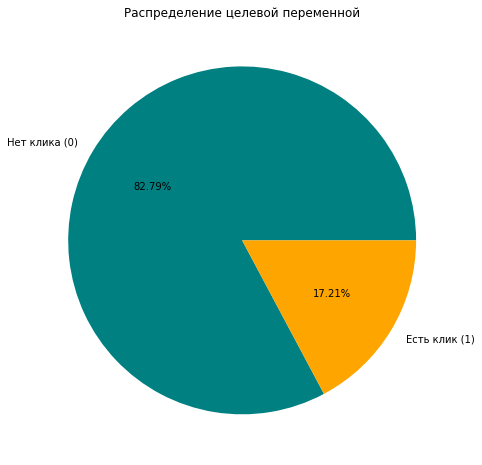

In [18]:
# Построим круговую диаграмму распределения
plt.figure(figsize=(8,8))
plt.pie(df['click'].value_counts(), 
        labels=['Нет клика (0)', 'Есть клик (1)'],
        colors = ['teal', 'orange'],
        autopct='%1.2f%%')
plt.title('Распределение целевой переменной')
plt.show()

Анализ распределения показал значительное преобладание отсутствия кликов (почти 83%), что указывает на наличие дисбаланса классов в целевой переменной. Это означает, что для оценки эффективности модели необходимо использовать метрики, нечувствительные к дисбалансу, такие как PR-AUC, а также F1-score для баланса между точностью и полнотой, что позволит оценить способность модели находить редкие, но важные события — клики.

#### 2.3 Анализ признаков <a id='Анализ-признаков'></a>

В пункте "[Описание данных](#Описание-данных)" перечислены признаки датасета. Как мы выяснили ранее, датасет содержит 21 числовой, 11 категориальных и 2 бинарных признаков. 

В машинном обучении не все признаки одинаково важны: некоторые содержат ключевую информацию для прогноза, другие — лишь технические идентификаторы или уникальные значения, которые не несут обобщённого смысла. Использование таких признаков может привести к переобучению, утечке данных или нарушению конфиденциальности.

Рассмотрим признаки более подробно и определим, все ли нужны для обучения модели. Удаление неинформативных признаков поможет упростить модель, повысить её интерпретируемость и улучшить качество предсказаний.

Признаки, которые можно удалить:

- `id` (уникальный идентификатор записи о показе баннера) не содержит никакой информации о поведении пользователя или контексте показа, не может быть использован для прогнозирования клика. Включение этого признака может привести к переобучению, т.к. модель может попытаться запомнить каждую запись по её id.
- `device_ip`(IP-адрес устройства) уникальны для каждого пользователя или сессии, но не несут обобщённой информации, полезной для прогнозирования клика. Кроме того, использование IP-адресов может нарушать политику конфиденциальности и законодательство о персональных данных.
- `device_id` (идентификатор браузера или устройства), аналогично id, уникален для каждого устройства, но не содержит обобщённой информации о поведении. Может привести к переобучению и утечке данных.
    
Признаки, которые можно оставить, но провести преобразование:

- `hour` (час, в который был показан баннер, в формате `YYMMDDHH`) может быть полезен, т.к. поведение пользователей часто зависит от времени суток. Однако, если в данных много уникальных значений и нет явной сезонности, этот признак можно преобразовать, например, в час дня и день недели.
- `site_id` (идентификатор веб-сайта, на котором был показан баннер), `app_id`(идентификатор рекламируемого мобильного приложения), `device_model`(модель устройства пользователя) могут быть полезны, если их преобразовать в категориальные с помощью кодирования (например, target encoding или frequency encoding), но использование их в исходном виде есть риск высокой кардинальности и переобучения.

Остальные признаки описывают контекст показа, характеристики устройства, сайта, приложения и баннера. Они могут быть полезны для модели и их следует оставить.

In [19]:
# Удалим 'id', 'device_ip', 'device_id'
df = df.drop(columns = ['id', 'device_ip', 'device_id'])

In [20]:
# Преобразуем 'hour' в час дня и день недели
# Преобразуем строку в формат datetime
df['date_time'] = pd.to_datetime(df['hour'], format='%y%m%d%H')

# Извлекаем час дня
df['hour_of_day'] = df['date_time'].dt.hour

# Извлекаем день недели (1=понедельник, 7=воскресенье)
df['day_of_week'] = df['date_time'].dt.dayofweek + 1

# Удаляем исходный столбец 'hour' и вспомогательный 'date_time'
df = df.drop(columns=['hour', 'date_time'])

# Вывод результата
print(df)

        site_id site_domain site_category    app_id app_domain app_category  \
0      d9750ee7    98572c79      f028772b  ecad2386   7801e8d9     07d7df22   
1      1fbe01fe    f3845767      28905ebd  ecad2386   7801e8d9     07d7df22   
2      d9750ee7    98572c79      f028772b  ecad2386   7801e8d9     07d7df22   
3      85f751fd    c4e18dd6      50e219e0  39cfef32   d9b5648e     0f2161f8   
4      1fbe01fe    f3845767      28905ebd  ecad2386   7801e8d9     07d7df22   
...         ...         ...           ...       ...        ...          ...   
49995  1fbe01fe    f3845767      28905ebd  ecad2386   7801e8d9     07d7df22   
49996  0a742914    510bd839      f028772b  ecad2386   7801e8d9     07d7df22   
49997  85f751fd    c4e18dd6      50e219e0  d36838b1   0e8616ad     0f2161f8   
49998  85f751fd    c4e18dd6      50e219e0  3c4b944d   2347f47a     0f2161f8   
49999  57fe1b20    5b626596      f028772b  ecad2386   7801e8d9     07d7df22   

      device_model  device_type  device_conn_type  

#### 2.4 Анализ пропущенных значений <a id='Анализ-пропущенных-значений'></a>

Перед построением модели необходимо проверить исходные данные на наличие пропусков. Корректная обработка отсутствующих значений является критически важным этапом, т.к. она напрямую влияет на качество обучения модели и достоверность итоговых выводов. Отсутствие значений в признаках может привести к смещению результатов и снижению качества обучения.

In [21]:
# Общее количество строк с пропущенными значениями
missing_rows_count = df.isna().any(axis=1).sum()
missing_rows_distr = ((missing_rows_count / total_rows)*100).round(2)

if missing_rows_count > 0:
    print(f'Общее количество строк с хотя бы одним пропуском: {missing_rows_count} ({missing_rows_distr}%)')
else:
    print('Пропуски в данных отсутствуют.')

Пропуски в данных отсутствуют.


#### 2.5 Анализ категориальных признаков <a id='Анализ-категориальных-признаков'></a>

В рамках анализа категориальных признаков необходимо:

- определить кардинальность каждого признака;
- на основе полученных данных выбрать стратегию кодирования (One-Hot Encoding или специальные методы).

In [22]:
# Выведем количество уникальных значений для каждого категориального признака, а также какую долю они составляют от общего числа значений
columns_info = classify_columns(df)
categorical_features = columns_info['categorical']
df_categorical = df[categorical_features]

unique_counts = df[categorical_features].nunique()
unique_distr = (unique_counts / total_rows * 100).round(2)
dtypes = df.dtypes.astype(str)

result = pd.DataFrame({
        'Тип данных': dtypes,
        'Уникальных значений': unique_counts,
        'Доля уникальных значений (%)': unique_distr
    }, index=df_categorical.columns)

print('КОЛИЧЕСТВО УНИКАЛЬНЫХ ЗНАЧЕНИЙ В КАЖДОМ КАТЕГОРИАЛЬНОМ ПРИЗНАКЕ:\n\n', result)

КОЛИЧЕСТВО УНИКАЛЬНЫХ ЗНАЧЕНИЙ В КАЖДОМ КАТЕГОРИАЛЬНОМ ПРИЗНАКЕ:

               Тип данных  Уникальных значений  Доля уникальных значений (%)
site_id           object                 1160                          2.32
site_domain       object                 1013                          2.03
site_category     object                   18                          0.04
app_id            object                  976                          1.95
app_domain        object                   67                          0.13
app_category      object                   22                          0.04
device_model      object                 2521                          5.04
ml_feature_2      object                    5                          0.01
ml_feature_7      object                    3                          0.01


In [23]:
def analyze_categorical_balance(df):
    '''
    Анализирует баланс классов для всех категориальных признаков в датафрейме.
    '''
    # Получаем список категориальных признаков
    columns_info = classify_columns(df)
    categorical_features = columns_info['categorical']

    # Анализируем баланс для каждого категориального признака
    for col in categorical_features:
        analyze_column_balance(df, col)
        
        # Получаем количество уникальных значений
        unique_count = df[col].nunique()
               
        print(f"\nИтого: признак '{col}' содержит {unique_count} уникальных значений(е,я).\n")
        print("=" * 70)

# Пример использования:
analyze_categorical_balance(df)

БАЛАНС КЛАССОВ ДЛЯ ПРИЗНАКА 'site_id':

          Значение Доля (%)
85f751fd     18011   36.02%
1fbe01fe      7968   15.94%
e151e245      3234    6.47%
d9750ee7      1262    2.52%
5b08c53b      1120    2.24%
...            ...      ...
a838a8a6         1    0.00%
34d1d55f         1    0.00%
c35edca1         1    0.00%
3f300029         1    0.00%
a4427a7b         1    0.00%

[1160 rows x 2 columns]

Итого: признак 'site_id' содержит 1160 уникальных значений(е,я).

БАЛАНС КЛАССОВ ДЛЯ ПРИЗНАКА 'site_domain':

          Значение Доля (%)
c4e18dd6     18645   37.29%
f3845767      7968   15.94%
7e091613      4088    8.18%
7687a86e      1544    3.09%
98572c79      1303    2.61%
...            ...      ...
85bb34e6         1    0.00%
4829c1c3         1    0.00%
bec2e626         1    0.00%
9abf866c         1    0.00%
0c34cac9         1    0.00%

[1013 rows x 2 columns]

Итого: признак 'site_domain' содержит 1013 уникальных значений(е,я).

БАЛАНС КЛАССОВ ДЛЯ ПРИЗНАКА 'site_category':

          

Алгоритмы машинного обучения, как правило, работают с числовыми данными. Категориальные признаки часто требуют преобразования в числовой формат. Рассмотрим каждый категориальный признак по отдельности.

| Признак | Кол-во уникальных значений | Метод кодирования | Обоснование выбора метода кодирования | Причины, по которым не рекомендуется удалять признак |
| --- | --- | --- | --- | --- |
| site_id | 1160 | Target Encoding | Высокая кардинальность. Метод позволяет сохранить информацию о влиянии конкретного сайта на кликабельность, не увеличивая размерность датасета. | Идентификатор сайта — ключевой контекст показа. Разные сайты имеют разную аудиторию и тематику. | 
| site_domain | 1013 | Target Encoding | Высокая кардинальность. Аналогично site_id, позволяет агрегировать информацию о домене в один числовой признак. | Домен сайта — сильный индикатор контекста и качества трафика. | 
| site_category | 18 | One-Hot Encoding | Низкая кардинальность. Применение OHE не приведёт к чрезмерному разрастанию признаков (всего +17 колонок). | Тематическая категория сайта — один из самых важных признаков, описывающий контекст показа. | 
| app_id | 976 | Target Encoding | Высокая кардинальность. Позволяет модели понять, какие приложения исторически показывают лучшую кликабельность. | Рекламируемое приложение определяет релевантность предложения для пользователя. | 
| app_domain | 67 | One-Hot Encoding | Средняя/низкая кардинальность. Метод OHE здесь эффективен и не создаст избыточной нагрузки на модель. | Домен приложения даёт ценную информацию о тематике и репутации рекламируемого продукта. | 
| app_category | 22 | One-Hot Encoding | Низкая кардинальность. Оптимальный выбор для сохранения категориальной природы признака без потери информации. | Категория приложения — высокоуровневый признак, описывающий суть рекламируемого продукта. | 
| device_model | 2521 | Target Encoding | Очень высокая кардинальность. Метод позволяет закодировать популярность модели устройства в один числовой признак, сохраняя информацию о влиянии на целевую переменную. | Модель устройства может косвенно указывать на предпочтения пользователя или технические возможности. | 
| ml_feature_2 | 5 | One-Hot Encoding | Низкая кардинальность и отсутствие иерархии. | Признак был сгенерирован в ходе предобработки и содержит извлечённую полезную информацию. | 
| ml_feature_7 | 3 | One-Hot Encoding | Очень низкая кардинальность. | Аналогично ml_feature_2. |

#### 2.6 Анализ выбросов и распределений <a id='Анализ-выбросов-и-распределений'></a>

Наличие выбросов может негативно сказаться на качестве анализа и работе моделей. Многие алгоритмы машинного обучения чувствительны к выбросам. Они могут «увести» линию регрессии или границу принятия решения в сторону аномалии, ухудшая точность прогнозов на обычных данных.

Выведем описательную статистику для всех признаков и визулизируем распределение данных.

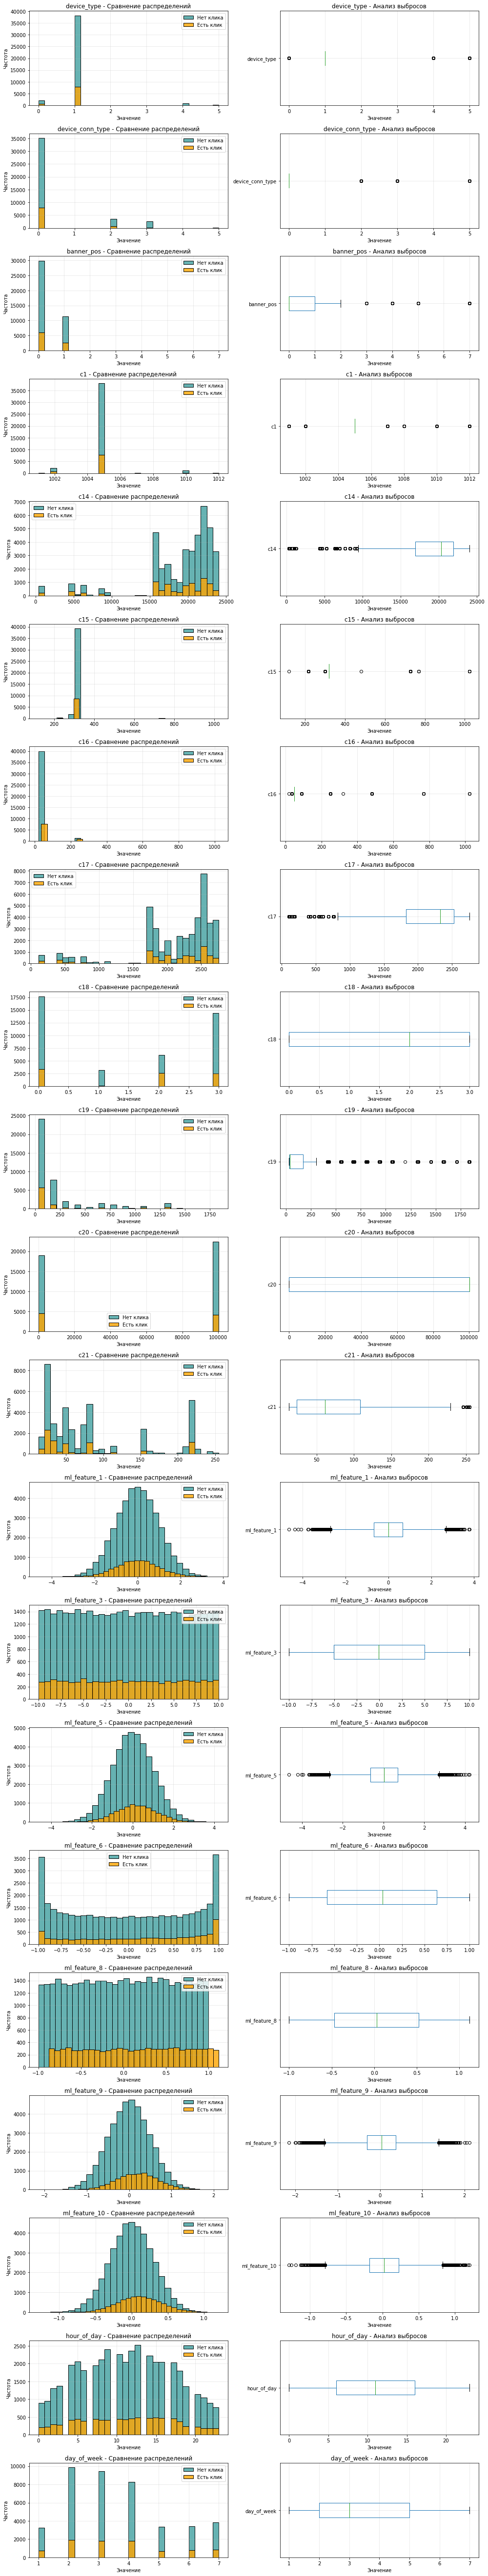

In [24]:
# Визуализация распределения числовых данных

# Классифицируем признаки
column_types = classify_columns(df)
numerical_cols = column_types['numerical']

# Определяем количество признаков и проверяем их наличие
n_features = len(numerical_cols)

if n_features == 0:
    print('Нет числовых признаков для визуализации.')
else:
    # Создаем сетку графиков: n_features строк и 2 столбца (гистограмма и боксплот)
    fig, axes = plt.subplots(n_features, 2, figsize=(14, 3.5 * n_features))

# Проходим по каждому числовому признаку
for i, col in enumerate(numerical_cols):
        
    # Получаем оси для текущего признака
    ax_hist = axes[i, 0] # Первая колонка - гистограмма
    ax_box = axes[i, 1] # Вторая колонка - боксплот

    # Гистограмма (сравнение распределений по целевой переменной)
    # Фильтруем данные для кликов и без кликов
    data_click = df.loc[df['click'] == 1, col]
    data_no_click = df.loc[df['click'] == 0, col]

    # Строим гистограмму для тех, кто НЕ кликнул
    sns.histplot(data_no_click, bins=30, color='teal', alpha=0.6, ax=ax_hist, label='Нет клика')
        
    # Поверх нее строим гистограмму для тех, кто КЛИКНУЛ
    sns.histplot(data_click, bins=30, color='orange', alpha=0.8, ax=ax_hist, label='Есть клик')
        
    ax_hist.set_title(f'{col} - Сравнение распределений')
    ax_hist.set_xlabel('Значение')
    ax_hist.set_ylabel('Частота')
    ax_hist.legend()
    ax_hist.grid(True, alpha=0.3)

    # boxplot (анализ выбросов)
    df[[col]].boxplot(ax=ax_box, vert=False)
    ax_box.set_title(f'{col} - Анализ выбросов')
    ax_box.set_xlabel('Значение')
    ax_box.set_ylabel('')
    ax_box.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

На ряде диаграмм распределения признаков наблюдаются выбросы. Это свидетельствует о наличии экстремальных значений, которые могут существенно искажать результаты статистического анализа и машинного обучения. Такие выбросы приводят к смещению средних значений и увеличению дисперсии, что снижает интерпретируемость метрик. При построении моделей прогнозирования наличие экстремальных значений может привести к переобучению.

Для повышения качества моделей и достоверности выводов необходимо провести предварительную обработку данных: применить методы фильтрации (например, правило межквартильного размаха), винзоризацию или логарифмическое преобразование для снижения влияния аномалий и уменьшения скошенности распределений.

Диаграммы сравнения распределения значений признаков для двух групп: тех, кто совершил клик, и тех, кто его не совершал, слабо различается между группами, но имеют небольшой сдвиг для некоторых признаков.

#### 2.7 Корреляции <a id='Корреляции'></a>

Для анализа взаимосвязей между всеми признаками воспользуемся матрицей корреляций Phik. 

Анализ матрицы позволит решить две ключевые задачи:

- определить признаки, наиболее сильно коррелирующие с целевой переменной;
- выявить пары признаков с высокой взаимной корреляцией, которые являются кандидатами на удаление для устранения избыточности данных.

interval columns not set, guessing: ['device_type', 'device_conn_type', 'banner_pos', 'c1', 'c14', 'c15', 'c16', 'c17', 'c18', 'c19', 'c20', 'c21', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10', 'click', 'hour_of_day', 'day_of_week']


C:\ProgramData\Anaconda3\lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable device_model is large: 2521. Are you sure this is not an interval variable? Analysis for pairs of variables including device_model can be slow.
  warnings.warn(
C:\ProgramData\Anaconda3\lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable site_domain is large: 1013. Are you sure this is not an interval variable? Analysis for pairs of variables including site_domain can be slow.
  warnings.warn(
C:\ProgramData\Anaconda3\lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable site_id is large: 1160. Are you sure this is not an interval variable? Analysis for pairs of variables including site_id can be slow.
  warnings.warn(


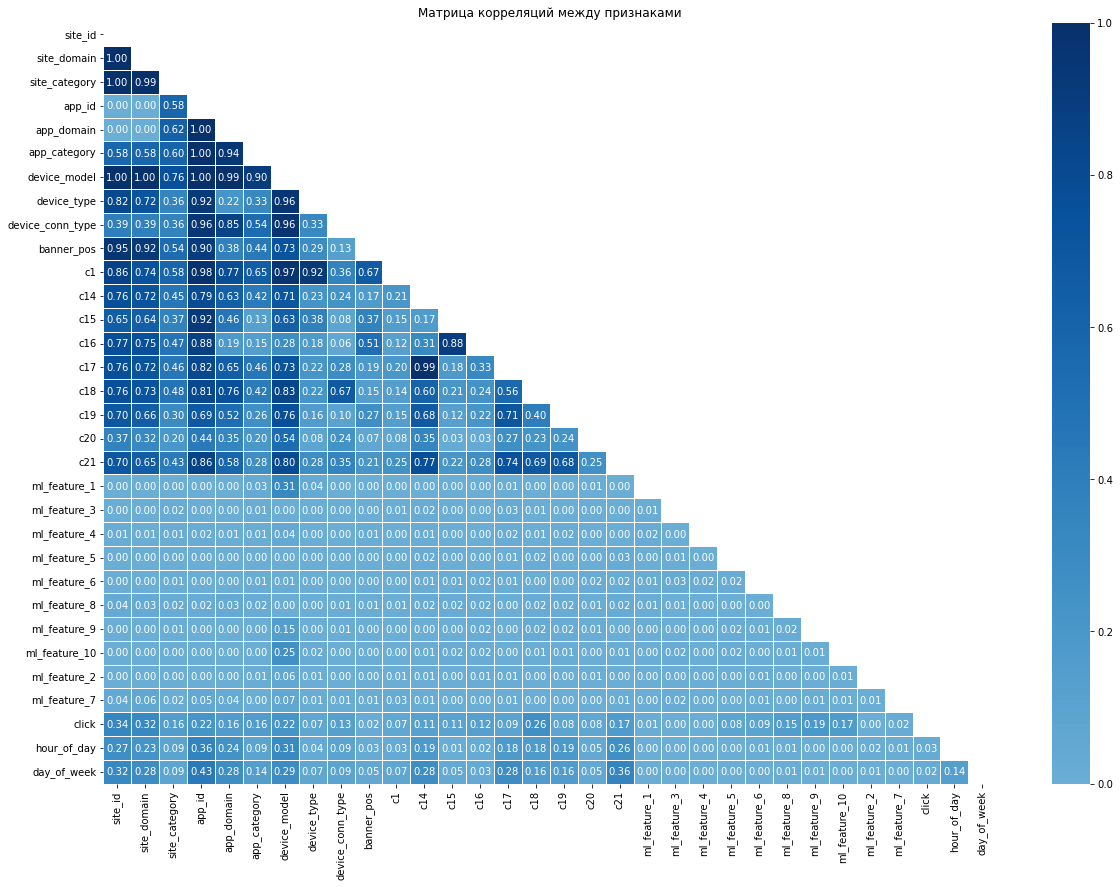

In [25]:
# Вычисляем матрицу корреляций Phi-K для всех признаков
phik_matrix = df.phik_matrix()

# Создаём маску для верхнего треугольника
mask = np.triu(np.ones_like(phik_matrix, dtype=bool))

# Строим тепловую карту с маской
plt.figure(figsize=(20, 14))
sns.heatmap(phik_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=0.5, center=0, mask=mask)
plt.title('Матрица корреляций между признаками')
plt.show()

In [26]:
# Преобразуем в длинный формат
corr_pairs = phik_matrix.unstack().reset_index()
corr_pairs.columns = ['var1', 'var2', 'corr']

# Убираем дубликаты
top_corr = corr_pairs[
    (corr_pairs['var1'] != corr_pairs['var2']) &
    (corr_pairs['var1'] < corr_pairs['var2'])
]

# Сортируем по абсолютному значению корреляции
top_corr = top_corr.sort_values(by='corr', key=abs, ascending=False).round(2)

# Берём топ-30
top_corr.head(30)

,var1,var2,corr
163,app_category,app_id,1.00
131,app_domain,app_id,1.00
32,site_domain,site_id,1.00
64,site_category,site_id,1.00
192,device_model,site_id,1.00
193,device_model,site_domain,1.00
102,app_id,device_model,1.00
65,site_category,site_domain,0.99
134,app_domain,device_model,0.99
366,c14,c17,0.99


In [27]:
# Сохраним полный DataFrame в Excel файл
# top_corr.to_excel('correlations.xlsx', index=False, sheet_name='Phik Correlations')
# print("Полная таблица корреляций сохранена в файл 'correlations.xlsx'")

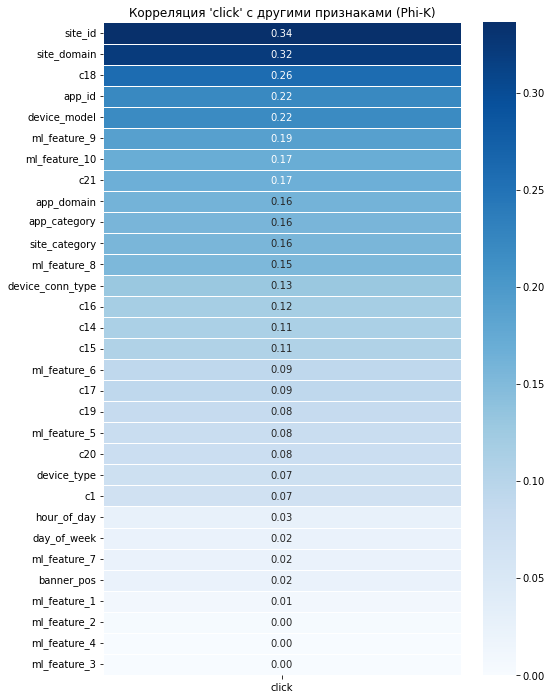

In [28]:
# Определяем с какими признаками целевая переменная показывает самую сильную связь
click_corr = phik_matrix.loc['click'].drop('click').sort_values(ascending=False)

# Визуализация матрицы корреляций
plt.figure(figsize=(8, 12))
sns.heatmap(click_corr.to_frame(), annot=True, cmap='Blues', fmt=".2f", linewidths=0.5)
plt.title("Корреляция 'click' с другими признаками (Phi-K)")
plt.show()

Удаление сильно коррелированных признаков помогает упростить модель, ускорить обучение и повысить её стабильность и интерпретируемость.

В качестве порога для удаления часто выбирают корреляцию по абсолютному значению выше 0.9, т.к. в этом случае признаки практически дублируют информацию друг друга, создавая избыточность. 

На основе этого критерия было принято решение удалить следующие признаки:

- app_category,
- app_domain,
- banner_pos,
- c1,
- c15,
- c17,
- device_conn_type,
- device_model,
- device_type,
- site_category,
- site_domain.

Для дальнейшего обучения модели было решено оставить:

- app_id,
- c14,
- site_id.

In [29]:
# Исключаем выбранные признаки
df = df.drop(columns = ['app_category', 'app_domain', 'banner_pos', 'c1', 'c15', 'c17', 
                        'device_conn_type', 'device_model', 'device_type', 'site_category', 
                        'site_domain'])

#### 2.8 Выводы по EDA <a id='Выводы-по-EDA'></a>

Датасет `ds_s16_ad_click_dataset.csv` содержит 50 000 строк и 34 столбца. Явные дубликаты и пропуски в данных отсутствуют, а типы данных соответствуют содержимому. Названия столбцов приведены к формату `snake_case`.

Основная проблема — дисбаланс классов в целевой переменной `click`: отсутствие клика наблюдается в 82,79% случаев, а сам клик — лишь в 17,21%. Это снижает надёжность метрики `Accuracy`. Для оценки модели следует использовать `Precision`, `Recall`, `F1-score` и `PR-AUC`, а при кросс-валидации применять стратифицированное разделение.

В ходе анализа были выявлены признаки с высокой кардинальностью (`device_ip`, `device_id`, `id`), которые являются техническими идентификаторами и не несут полезной информации для модели. Их использование привело бы к переобучению, поэтому они были удалены. Также обнаружены выбросы в распределении числовых признаков, способные исказить анализ. Для их обработки можно применить фильтрацию по межквартильному размаху или винзоризацию.

Анализ корреляций показал сильную связь между рядом признаков, что говорит о мультиколлениарности. Признаки с коэффициентом корреляции выше 0.9 были отфильтрованы.

In [30]:
# Список столбцов после изменений
new_columns = df.columns.tolist()

# Удаленные столбцы
removed_columns = list(set(original_columns) - set(new_columns))

# Добавленные столбцы
added_columns = list(set(new_columns) - set(original_columns))

# Выведем результаты
print('Удалены признаки:', removed_columns)
print('\nДобавлены признаки:', added_columns)
print('\nКоличество признаков после удаления (с учетом целевой переменной):', len(new_columns))

Удалены признаки: ['site_domain', 'device_conn_type', 'c15', 'app_category', 'hour', 'site_category', 'id', 'app_domain', 'device_ip', 'device_id', 'device_model', 'banner_pos', 'c17', 'device_type', 'c1']

Добавлены признаки: ['hour_of_day', 'day_of_week']

Количество признаков после удаления (с учетом целевой переменной): 21


In [31]:
phik_matrix = df.phik_matrix()
click_corr_final = phik_matrix.loc['click'].drop('click').sort_values(ascending=False)

# Создаем DataFrame для таблицы
corr_table = pd.DataFrame({
    "Признак": click_corr_final.index,
    "Корреляция с 'click'": click_corr_final.values.round(2)
})

# Сортируем по убыванию
corr_table = corr_table.sort_values(by="Корреляция с 'click'", ascending=False)

# Выводим топ-30 признаков для анализа
print(f'ТОП-5 КОРРЕЛЯЦИИ ПРИЗНАКОВ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:\n')
print(corr_table.head(5))

interval columns not set, guessing: ['c14', 'c16', 'c18', 'c19', 'c20', 'c21', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10', 'click', 'hour_of_day', 'day_of_week']


C:\ProgramData\Anaconda3\lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable site_id is large: 1160. Are you sure this is not an interval variable? Analysis for pairs of variables including site_id can be slow.
  warnings.warn(


ТОП-5 КОРРЕЛЯЦИИ ПРИЗНАКОВ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:

         Признак  Корреляция с 'click'
0        site_id                  0.34
1            c18                  0.26
2         app_id                  0.22
3   ml_feature_9                  0.19
4  ml_feature_10                  0.17


Наиболее значимыми факторами, влияющими на кликабельность, являются `site_id` (0.34), `site_domain` (0.32) и `с18` (0.26).

Для дальнейшего повышения качества модели необходимо обработать выбросы закодировать категориальные переменные с учётом их кардинальности.

## 3. Разделение данных на выборки <a id='Разделение-данных-на-выборки'></a>

#### 3.1 Разделение данных <a id='Разделение-данных'></a>

Перед обучением модели необходимо разделить исходный датасет на независимые выборки: 
- обучающую (train), которая используется непосредственно для обучения модели;
- тестовую (test), которая применяется однократно в самом конце для финальной, объективной оценки качества уже готовой модели.

Ключевым требованием при таком разделении является сохранение исходного распределения целевой переменной (`click`) во указанных выборках. Это гарантирует, что модель будет обучаться и оцениваться на данных, статистически идентичных реальным. Для этого используется стратифицированное разделение.

In [32]:
# Разделим признаки и целевую переменную
X = df.drop(columns='click')
y = df['click']

# Разделяем данные на обучение и тест
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=y
)

# Разделяем обучающую выборку на обучение и калибровку
X_train, X_calib, y_train, y_calib = train_test_split(
    X_train_full, y_train_full,
    test_size=0.3,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=y_train_full
)
    
# Выводим размеры выборок
print("Размер X_train:", X_train.shape)
print("Размер y_train:", y_train.shape)
print("Размер X_calib:", X_calib.shape)
print("Размер y_calib:", y_calib.shape)
print("Размер X_test:", X_test.shape)
print("Размер y_test:", y_test.shape)

Размер X_train: (28000, 20)
Размер y_train: (28000,)
Размер X_calib: (12000, 20)
Размер y_calib: (12000,)
Размер X_test: (10000, 20)
Размер y_test: (10000,)


#### 3.2 Проверка разделения данных <a id='Проверка-разделения-данных'></a>

После разделения данных необходимо убедиться в корректности этого процесса. Проверим, что распределение целевой переменной сохранилось в обучающей и тестовой выборках.

In [33]:
def analyze_class_distribution(y_train, y_test):
    '''
    Анализирует распределение классов (0 и 1) в обучающей и тестовой выборках.

    Параметры:
    y_train — целевая переменная обучающей выборки
    y_calib — целевая переменная калибровочной выборки
    y_test — целевая переменная тестовой выборки

    Возвращает:
    pd.DataFrame с информацией о распределении классов по выборкам
    '''
    # Собираем данные по каждой выборке
    datasets = [
        ('Обучающая', y_train),
        ('Калибровочная', y_calib),
        ('Тестовая', y_test)
    ]

    ### Считаем общее количество записей для вычисления процента от общего
    total_records = sum(len(y) for _, y in datasets)    
    
    
    result_data = []
    
    print('РАСПРЕДЕЛЕНИЕ КЛАССОВ В ВЫБОРКАХ:\n')

    for name, y in datasets:
        # Абсолютное количество
        abs_counts = y.value_counts().sort_index()
        count_0 = abs_counts.get(0, 0)
        count_1 = abs_counts.get(1, 0)

        # Доли в процентах
        rel_counts = y.value_counts(normalize=True).sort_index()
        percent_0 = round(rel_counts.get(0, 0) * 100, 2)
        percent_1 = round(rel_counts.get(1, 0) * 100, 2)

        # Процент от общего числа записей
        total_in_set = len(y)
        percent_of_total = round(total_in_set / total_records * 100, 2) if total_records else 0.0

        result_data.append({
            'Выборка': name,
            'Нет клика (0), %': percent_0,
            'Есть клик (1), %': percent_1,
            'Всего записей': total_in_set,
            '% от общего числа': percent_of_total
        })

    # Формируем итоговый датафрейм
    result_df = pd.DataFrame(result_data)

    return result_df

# Применение функции и вывод результатов
class_distribution = analyze_class_distribution(y_train, y_test)
print(class_distribution.to_string(index=False))

РАСПРЕДЕЛЕНИЕ КЛАССОВ В ВЫБОРКАХ:

      Выборка  Нет клика (0), %  Есть клик (1), %  Всего записей  % от общего числа
    Обучающая             82.80             17.20          28000               56.0
Калибровочная             82.79             17.21          12000               24.0
     Тестовая             82.79             17.21          10000               20.0


Разделение данных было выполнено стратифицированным методом с соотношением 80%/20% для обучающей, и тестовой выборок соответственно.<br>Анализ распределения целевой переменной `click` в полученных выборках показал, что пропорция классов была успешно сохранена.<br>Таким образом, все выборки являются сбалансированными и пригодными для дальнейшего использования.

## 4. Предобработка данных <a id='Предобработка-данных'></a>

#### 4.1 Создание пайплайнов для предобработки данных <a id='Создание-пайплайнов-для-предобработки-данных'></a>

Качество предобработки данных напрямую влияет на эффективность модели. Пайплайны автоматизируют и стандартизируют этот процесс, обеспечивая единообразие преобразований для обучающих и тестовых выборок.

Для числовых признаков масштабируем данные с помощью `StandardScaler`.<br>
Для категориальных признаков применим кодирование, описанное в [п.2.5 "Анализ категориальных признаков"](#Анализ-категориальных-признаков).

In [34]:
# Разделение признаков на обучающей выборке
feature_types = classify_columns(X_train)

# Получаем списки признаков
numerical_features = feature_types['numerical']
categorical_features = feature_types['categorical']
binary_features = feature_types['binary']

##### Пайплайн для числовых признаков

In [35]:
# Трансформер для обработки выбросов (заменяет аномальные значения на границы IQR)
def handle_outliers_iqr(X):
    """
    Винзоризация числовых признаков по методу IQR.
    Значения вне диапазона [Q1 - 1.5*IQR, Q3 + 1.5*IQR] заменяются на границы.
    """
    X = np.asarray(X)

    for i in range(X.shape[1]):
        col = X[:, i]
        q1, q3 = np.percentile(col, [25, 75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        X[:, i] = np.clip(col, lower, upper)

    return X

# Трансформер для пайплайна
outlier_transformer = FunctionTransformer(handle_outliers_iqr, validate=False)

# Пайплайн для числовых признаков
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer()),
    ('scaler', StandardScaler())
])

##### Пайплайн для обработки категориальных признаков

In [36]:
# Выведем категориальные признаки после преобразований
columns_info = classify_columns(df)
categorical_features = columns_info['categorical']

print(categorical_features)

['site_id', 'app_id', 'ml_feature_2', 'ml_feature_7']


In [37]:
# Группируем признаки по методу кодирования
high_cardinality = ['site_id', 'app_id'] # Target Encoding
low_cardinality = ['ml_feature_2', 'ml_feature_7'] # One-Hot Encoding

# Трансформер для Target Encoding
target_encoder = TargetEncoder(cols=high_cardinality, smoothing=10)

# Трансформер для One-Hot Encoding
ohe_encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

# Собираем пайплайн
categorical_pipeline = ColumnTransformer(
    transformers=[
        ('target', target_encoder, high_cardinality),
        ('ohe', ohe_encoder, low_cardinality)
    ])

##### Пайплайн для обработки бинарных признаков

Поскольку в данных нет пропусков, то бинарный признак `ml_feature_4` не требуют никакой специальной обработки. Передадим его дальше без изменений с помощью параметра `remainder='passthrough'` в ColumnTransformer.

#### 4.2 Объединение пайплайнов <a id='Объединение-пайплайнов'></a>

Соберём все части в один общий пайплайн с помощью главного ColumnTransformer.

In [38]:
# Итоговый пайплайн
final_preprocessing = ColumnTransformer(
    transformers=[
        ('numeric', numeric_pipeline, numerical_features),
        ('categorical', categorical_pipeline, categorical_features)],
    remainder='passthrough'
)

# Обучаем предобработку на train
X_train_processed = final_preprocessing.fit_transform(X_train, y_train)
# Применяем её к calib и test
X_calib_processed = final_preprocessing.transform(X_calib)
X_test_processed = final_preprocessing.transform(X_test)

Перед обучением модели данные прошли стандартизированную предобработку с учётом типа каждого признака. Это гарантирует, что алгоритм получит «чистые» и сопоставимые входные данные.

## 5. Отбор признаков <a id='Отбор-признаков'></a>

Отбор признаков помогает убрать «шум», ускорить обучение и повысить качество модели.

In [39]:
# Сохраняем имена столбцов ДО преобразований
original_feature_names = X_train.columns.tolist()
print(f'Исходное количество признаков: {len(original_feature_names)}')
print(f'\nИмена признаков: {original_feature_names}')

Исходное количество признаков: 20

Имена признаков: ['site_id', 'app_id', 'c14', 'c16', 'c18', 'c19', 'c20', 'c21', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10', 'ml_feature_2', 'ml_feature_7', 'hour_of_day', 'day_of_week']


#### 5.1 Фильтрационные методы <a id='Фильтрационные-методы'></a>

Для первичного отбора признаков будут использованы фильтрационные методы. Данный подход позволяет оценить релевантность каждого признака. В рамках этого этапа будет проведён анализ корреляции с целевой переменной, отбор топовых признаков и удаление признаков с низкой дисперсией.

In [40]:
# Считаем корреляцию для всех признаков
full_corr = []
for col in X_train.columns:
    try:
        corr = np.corrcoef(X_train[col], y_train)[0, 1]
        full_corr.append((col, corr))
    except:
        full_corr.append((col, np.nan))

# Создаём полную таблицу корреляций
corr_table_full = pd.DataFrame(full_corr, columns=["Признак", "Корреляция с 'click'"])
corr_table_full["Корреляция с 'click'"] = corr_table_full["Корреляция с 'click'"].round(2)

# Сортируем и выводим
corr_table = corr_table_full.sort_values(by="Корреляция с 'click'", ascending=False)
print(f'Количество признаков ДО фильтрации: {len(corr_table_full)}')
print(f'\nКОРРЕЛЯЦИИ ПРИЗНАКОВ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:\n')
print(corr_table)

Количество признаков ДО фильтрации: 20

КОРРЕЛЯЦИИ ПРИЗНАКОВ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:

          Признак  Корреляция с 'click'
14   ml_feature_9                  0.15
3             c16                  0.14
15  ml_feature_10                  0.13
13   ml_feature_8                  0.08
11   ml_feature_5                  0.06
12   ml_feature_6                  0.06
4             c18                  0.02
19    day_of_week                  0.01
5             c19                  0.00
8    ml_feature_1                 -0.00
9    ml_feature_3                  0.00
10   ml_feature_4                 -0.00
18    hour_of_day                  0.00
6             c20                 -0.05
2             c14                 -0.07
7             c21                 -0.07
0         site_id                   NaN
1          app_id                   NaN
16   ml_feature_2                   NaN
17   ml_feature_7                   NaN


Значение корреляции «NaN» означает, что данный признак является константным в рамках обучающей выборки (X_train). Изменение корреляций в обучающей выборке после предобработки по сравнению с исходными данными связано с трансформацией данных, обработкой выбросов, масштабированием и кодированием.

Удалим с помощью `VarianceThreshold` все столбцы, чья дисперсия не превышает 0.01. Это позволит на раннем этапе очистки данных избавиться от бесполезной информации, которая не несёт никакой ценности для обучения модели.

In [41]:
# Применяем VarianceThreshold
selector = VarianceThreshold(threshold=0.01)
X_train_vt = selector.fit_transform(X_train_processed)
X_calib_vt = selector.transform(X_calib_processed)
X_test_vt = selector.transform(X_test_processed)

# Получаем индексы оставшихся признаков
vt_indices = selector.get_support(indices=True)
print(f'Количество признаков после VarianceThreshold: {len(vt_indices)}')

Количество признаков после VarianceThreshold: 24


#### 5.2 Методы-обёртки <a id='Методы-обёртки'></a>

Чтобы уменьшить размерность данных, убрать «шум» и оставить только те признаки, которые вносят наибольший вклад в предсказание целевой переменной, воспользуемся методом рекурсивного отбора признаков `RFE` (Recursive Feature Elimination). Это повсит интерпретируемость модели и может улучшить её качество.

In [42]:
# Выбираем модель для RFE
model = LogisticRegression(max_iter=1000)

# Применяем RFE (оставляем 10 лучших признаков)
rfe = RFE(estimator=model, n_features_to_select=10)

X_train_selected = rfe.fit_transform(X_train_vt, y_train)
X_calib_selected = rfe.transform(X_calib_vt)
X_test_selected = rfe.transform(X_test_vt)

# Получаем индексы признаков, выбранных RFE
rfe_indices = rfe.get_support(indices=True)
print(f'Количество признаков после RFE: {len(rfe_indices)}')

Количество признаков после RFE: 10


#### 5.3 Финальный набор признаков <a id='Финальный-набор-признаков'></a>

Объединяем результаты `VarianceThreshold` и `RFE`, чтобы получить финальный набор признаков:

In [43]:
# Итоговый отбор признаков
selected_features = rfe.support_

n_features = selected_features.sum()
print(f'Отобрано признаков: {n_features}. \nИтоговая размерность: {X_train_selected.shape}.')

Отобрано признаков: 10. 
Итоговая размерность: (28000, 10).


## 6. Обучение базовой модели <a id='Обучение-базовой-модели'></a>

### 6.1 Обучение `DummyClassifier`  <a id='DummyClassifier'></a>

Для оценки качества моделей необходимо иметь точку отсчёта. В качестве baseline используем простейший алгоритм, который предсказывает классы случайным образом или по самому частому значению, а именно `DummyClassifier`. Это позволит понять, решает ли реальная модель задачу или работает не лучше случайного угадывания.

In [44]:
# Определяем метрики
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision'
}

# Настройка кросс-валидации
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Словарь для хранения результатов
results = {}


# Базовая модель DummyClassifier
dummy_model = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy_scores = cross_validate(
    dummy_model,
    X_train,
    y_train,
    cv=kfold,
    scoring=scoring
)

results['DummyClassifier'] = {
    'Accuracy': dummy_scores['test_accuracy'].mean(),
    'Precision': dummy_scores['test_precision'].mean(),
    'Recall': dummy_scores['test_recall'].mean(),
    'F1-score': dummy_scores['test_f1'].mean(),
    'ROC-AUC': dummy_scores['test_roc_auc'].mean(),
    'PR-AUC': dummy_scores['test_pr_auc'].mean()
}

### 6.2 Обучение `LogisticRegression` <a id='LogisticRegression'></a>

Обучим модель логистической регрессии (LogisticRegression) на отобранных ранее признаках.

In [45]:
# LogisticRegression
# Создаем пайплайн с предобработкой и моделью
logreg_pipeline = Pipeline([
    ('preprocessor', final_preprocessing),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

# Передаем в кросс-валидацию данные без предобработки и пайплайн
logreg_scores = cross_validate(
    logreg_pipeline,
    X_train,
    y_train,
    cv=kfold,
    scoring=scoring,
    n_jobs=-1
)

# Сохраняем результаты
results['LogisticRegression'] = {
    'Accuracy': logreg_scores['test_accuracy'].mean(),
    'Precision': logreg_scores['test_precision'].mean(),
    'Recall': logreg_scores['test_recall'].mean(),
    'F1-score': logreg_scores['test_f1'].mean(),
    'ROC-AUC': logreg_scores['test_roc_auc'].mean(),
    'PR-AUC': logreg_scores['test_pr_auc'].mean()
}

### 6.3 Обучение `SVC` <a id='SVC'></a>

Обучим модель метода опорных векторов (SVC) с линейным ядром.

In [46]:
# SVC
svc_pipeline = Pipeline([
    ('preprocessor', final_preprocessing),
    ('classifier', SVC(probability=True, random_state=RANDOM_STATE))
])

# Применяем кросс-валидацию
svc_scores = cross_validate(
    svc_pipeline,
    X_train,
    y_train,
    cv=kfold,
    scoring=scoring,
    n_jobs=-1
)

# Сохраняем усреднённые результаты в словарь results
results['SVC_Linear'] = {
    'Accuracy': svc_scores['test_accuracy'].mean(),
    'Precision': svc_scores['test_precision'].mean(),
    'Recall': svc_scores['test_recall'].mean(),
    'F1-score': svc_scores['test_f1'].mean(),
    'ROC-AUC': svc_scores['test_roc_auc'].mean(),
    'PR-AUC': svc_scores['test_pr_auc'].mean()
}

### 6.4 Сравнение моделей <a id='Сравнение-моделей'></a>

Сравним качество обученных моделей.

In [47]:
df = pd.DataFrame(results).T.round(4)

models_to_show = ['DummyClassifier', 'LogisticRegression', 'SVC_Linear']
df = df.loc[models_to_show]

# Выводим итоговую таблицу
print('СРАВНЕНИЕ МОДЕЛЕЙ ПО МЕТРИКАМ:\n')
print(df.to_string())

СРАВНЕНИЕ МОДЕЛЕЙ ПО МЕТРИКАМ:

                    Accuracy  Precision  Recall  F1-score  ROC-AUC  PR-AUC
DummyClassifier       0.7181     0.1718  0.1671    0.1694   0.4999  0.1721
LogisticRegression    0.8362     0.6068  0.1393    0.2263   0.7495  0.4058
SVC_Linear            0.8317     0.6217  0.0556    0.1021   0.6821  0.3475


In [48]:
# Обучаем лучшую версию модели
best_model = logreg_pipeline.fit(X_train, y_train)

## 7. Подбор гиперпараметров <a id='Подбор-гиперпараметров'></a>

#### 7.1 Сетка гиперпараметров <a id='Сетка-гиперпараметров'></a>

Определим сетки параметров для каждой модели.

In [49]:
# Параметры для LogisticRegression
logreg_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__class_weight': [None, 'balanced'],
    'classifier__solver': ['liblinear', 'lbfgs']
}

# Параметры для SVC
svc_param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['linear'],
    'classifier__class_weight': [None, 'balanced']
}

#### 7.2 Grid Search  с кросс-валидацией <a id='Grid-Search-с-кросс-валидацией'></a>

Создадим цикл для обучения обеих моделей с помощью GridSearchCV.

In [50]:
# Теперь мы создаём пайплайн внутри цикла для каждой модели и передаём его в GridSearchCV.

In [51]:
# Общие настройки
scoring_metric = 'average_precision'
all_models_results = {}
best_models = {}

# 1. LogisticRegression
print("\n=== ПОДБОР ГИПЕРПАРАМЕТРОВ ДЛЯ LogisticRegression ===")

logreg_pipeline = Pipeline([
    ('preprocessor', final_preprocessing),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

logreg_grid = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=logreg_param_grid,
    cv=kfold,
    scoring=scoring_metric,
    refit=True,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

logreg_grid.fit(X_train, y_train)

print(f'Лучший PR-AUC на кросс-валидации: {logreg_grid.best_score_:.4f}')
print(f'Лучшие параметры: {logreg_grid.best_params_}')

results_df = pd.DataFrame(logreg_grid.cv_results_)
top_configs = results_df.sort_values(['mean_test_score', 'rank_test_score'], ascending=[False, True]).head(10)
param_cols = [col for col in top_configs.columns if col.startswith('param_')]
output_df = top_configs[param_cols + ['mean_test_score']]
output_df.columns = [col.replace('param_', '') for col in output_df.columns]
print('\nТоп-10 конфигураций гиперпараметров:')
print(output_df.to_string(index=False))

all_models_results['LogisticRegression'] = {
    'best_params': logreg_grid.best_params_,
    'best_score': logreg_grid.best_score_,
    'cv_results': logreg_grid.cv_results_
}

best_models['LogisticRegression'] = logreg_grid.best_estimator_

# 2. SVC
print("\n=== ПОДБОР ГИПЕРПАРАМЕТРОВ ДЛЯ SVC ===")

svc_pipeline = Pipeline([
    ('preprocessor', final_preprocessing),
    ('classifier', SVC(probability=True, random_state=RANDOM_STATE))
])

svc_grid = GridSearchCV(
    estimator=svc_pipeline,
    param_grid=svc_param_grid,
    cv=kfold,
    scoring=scoring_metric,
    refit=True,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
    error_score='raise'
)

svc_grid.fit(X_train, y_train)

print(f'Лучший PR-AUC на кросс-валидации: {svc_grid.best_score_:.4f}')
print(f'Лучшие параметры: {svc_grid.best_params_}')

results_df = pd.DataFrame(svc_grid.cv_results_)
top_configs = results_df.sort_values(['mean_test_score', 'rank_test_score'], 
                                    ascending=[False, True]).head(10)
param_cols = [col for col in top_configs.columns if col.startswith('param_')]
output_df = top_configs[param_cols + ['mean_test_score']]
output_df.columns = [col.replace('param_', '') for col in output_df.columns]
print('\nТоп-10 конфигураций гиперпараметров:')
print(output_df.to_string(index=False))

all_models_results['SVC'] = {
    'best_params': svc_grid.best_params_,
    'best_score': svc_grid.best_score_,
    'cv_results': svc_grid.cv_results_
}

best_models['SVC'] = svc_grid.best_estimator_


=== ПОДБОР ГИПЕРПАРАМЕТРОВ ДЛЯ LogisticRegression ===
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Лучший PR-AUC на кросс-валидации: 0.4058
Лучшие параметры: {'classifier__C': 1, 'classifier__class_weight': None, 'classifier__solver': 'lbfgs'}

Топ-10 конфигураций гиперпараметров:
classifier__C classifier__class_weight classifier__solver  mean_test_score
            1                     None              lbfgs         0.405758
            1                     None          liblinear         0.405754
           10                     None          liblinear         0.405472
           10                     None              lbfgs         0.405469
            1                 balanced          liblinear         0.404230
            1                 balanced              lbfgs         0.404222
           10                 balanced          liblinear         0.404112
           10                 balanced              lbfgs         0.404111
          0.1             

#### 7.3 Анализ результатов <a id='Анализ-результатов'></a>

In [52]:
# Имя лучшей модели по метрике из кросс-валидации
best_model_name = max(all_models_results, key=lambda k: all_models_results[k]['best_score'])
best_cv_score = all_models_results[best_model_name]['best_score']

print(f"\nЛучшая модель по кросс-валидации: {best_model_name} с PR-AUC = {best_cv_score:.4f}")


Лучшая модель по кросс-валидации: LogisticRegression с PR-AUC = 0.4058


## 8. Финальная модель <a id='Финальная-модель'></a>

#### 8.1 Обучение финальной модели <a id='Обучение-финальной-модели'></a>

In [53]:
# Обучение финальной модели на ВСЕХ данных
best_model_name = max(all_models_results, key=lambda k: all_models_results[k]['best_score'])
final_pipeline = best_models[best_model_name]

print('\n=== ИНФОРМАЦИЯ О ФИНАЛЬНОЙ МОДЕЛИ ===')
print(f'Лучшая модель: {best_model_name}')
print(f"Лучшие параметры: {all_models_results[best_model_name]['best_params']}")
print(f"Лучший PR-AUC на кросс-валидации: {all_models_results[best_model_name]['best_score']:.4f}")


=== ИНФОРМАЦИЯ О ФИНАЛЬНОЙ МОДЕЛИ ===
Лучшая модель: LogisticRegression
Лучшие параметры: {'classifier__C': 1, 'classifier__class_weight': None, 'classifier__solver': 'lbfgs'}
Лучший PR-AUC на кросс-валидации: 0.4058


#### 8.2 Метрики на тестовой выборке <a id='Метрики-на-тестовой-выборке'></a>

In [54]:
# Делаем предсказания вероятностей
y_pred_proba = final_pipeline.predict_proba(X_test)[:, 1]
y_pred_class = final_pipeline.predict(X_test)

# Рассчитываем метрики
test_metrics = {
    'PR-AUC': average_precision_score(y_test, y_pred_proba),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba),
    'Brier Score': brier_score_loss(y_test, y_pred_proba),
    'Precision': precision_score(y_test, y_pred_class),
    'Recall': recall_score(y_test, y_pred_class),
    'F1-score': f1_score(y_test, y_pred_class)
}

# Выводим основные метрики
print('\nМЕТРИКИ ФИНАЛЬНОЙ МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ:\n')
for metric, value in test_metrics.items():
    print(f'{metric:<15} {value:.4f}')


МЕТРИКИ ФИНАЛЬНОЙ МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ:

PR-AUC          0.3984
ROC-AUC         0.7438
Brier Score     0.1250
Precision       0.5985
Recall          0.1412
F1-score        0.2285


Модель хорошо разделяет пользователей на «кликнет» и «не кликнет», что подтверждается значением ROC-AUC (0.74). Однако она плохо откалибрована и имеет низкую полноту Recall, т.е. пропускает большинство реальных кликов.

#### 8.3 Веса модели <a id='Веса-модели'></a>

В этом разделе проанализируем веса модели для определения самых влиятельных признаков. Сопоставление коэффициентов с именами признаков после предобработки позволяет сделать выводы об их вкладе в итоговое предсказание.

In [55]:
# Проверяем, есть ли у модели внутри пайплайна атрибут с весами
if hasattr(final_pipeline.named_steps['classifier'], 'coef_'):
    
    # Извлекаем веса из пайплайна
    coefficients = final_pipeline.named_steps['classifier'].coef_[0]
    feature_names = [f'feature_{i}' for i in range(len(coefficients))]

    weights_df = pd.DataFrame({
        'Признак': feature_names,
        'Коэффициент': coefficients
    })

    weights_df_sorted = weights_df.sort_values(by='Коэффициент', key=abs, ascending=False)

    # Выводим топ-10 признаков
    print("САМЫЕ ВАЖНЫЕ ПРИЗНАКИ (ТОП-10):\n")
    print(weights_df_sorted.head(10).to_string(index=False))

else:
    print(f"\nМодель {best_model_name} не имеет линейных коэффициентов для интерпретации.")

САМЫЕ ВАЖНЫЕ ПРИЗНАКИ (ТОП-10):

   Признак  Коэффициент
feature_16     8.562880
feature_15     5.663856
feature_11     0.400440
feature_12     0.346602
feature_10     0.211477
 feature_8     0.163111
 feature_9     0.160495
feature_24    -0.126700
feature_22     0.091900
feature_19    -0.079652


In [56]:
# Интерпретация результатов
print('\n' + '='*70)
print('ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ')
print('='*70)

if 'weights_df' not in locals():
    print("\nКЛЮЧЕВЫЕ ВЫВОДЫ: Интерпретация невозможна для выбранной модели.")
else:
    print("\nКЛЮЧЕВЫЕ ВЫВОДЫ:")
    print(f"• Всего признаков в модели: {len(coefficients)}")
    print(f"• Количество значимых признаков (|коэф| > 0.1): {(abs(coefficients) > 0.1).sum()}")
    print(f"• Максимальный коэффициент: {coefficients.max():.4f}")
    print(f"• Минимальный коэффициент: {coefficients.min():.4f}")

    # Анализ самых важных признаков
    top_positive = weights_df[weights_df['Коэффициент'] > 0].head(3)
    top_negative = weights_df[weights_df['Коэффициент'] < 0].head(3)

    print(f"\nТРИ САМЫХ ВЛИЯТЕЛЬНЫХ ПРИЗНАКА, УВЕЛИЧИВАЮЩИХ ВЕРОЯТНОСТЬ КЛАССА:")
    for _, row in top_positive.iterrows():
        print(f"  • {row['Признак']}: {row['Коэффициент']:.4f} — увеличивает вероятность положительного класса")

    print(f"\nТРИ САМЫХ ВЛИЯТЕЛЬНЫХ ПРИЗНАКА, УМЕНЬШАЮЩИХ ВЕРОЯТНОСТЬ КЛАССА:")
    for _, row in top_negative.iterrows():
        print(f"  • {row['Признак']}: {row['Коэффициент']:.4f} — уменьшает вероятность положительного класса")


ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ

КЛЮЧЕВЫЕ ВЫВОДЫ:
• Всего признаков в модели: 26
• Количество значимых признаков (|коэф| > 0.1): 8
• Максимальный коэффициент: 8.5629
• Минимальный коэффициент: -0.1267

ТРИ САМЫХ ВЛИЯТЕЛЬНЫХ ПРИЗНАКА, УВЕЛИЧИВАЮЩИХ ВЕРОЯТНОСТЬ КЛАССА:
  • feature_3: 0.0645 — увеличивает вероятность положительного класса
  • feature_8: 0.1631 — увеличивает вероятность положительного класса
  • feature_9: 0.1605 — увеличивает вероятность положительного класса

ТРИ САМЫХ ВЛИЯТЕЛЬНЫХ ПРИЗНАКА, УМЕНЬШАЮЩИХ ВЕРОЯТНОСТЬ КЛАССА:
  • feature_0: -0.0769 — уменьшает вероятность положительного класса
  • feature_1: -0.0046 — уменьшает вероятность положительного класса
  • feature_2: -0.0174 — уменьшает вероятность положительного класса


## 9. Калибровка модели <a id='Калибровка-модели'></a>

Как показал анализ, модель хорошо разделяет классы, но её предсказанные вероятности не соответствуют реальной уверенности. Для исправления этого недостатка и получения более надёжных вероятностных оценок выполним калибровку модели.

#### 9.1 Текущая калибровка <a id='Текущая-калибровка'></a>

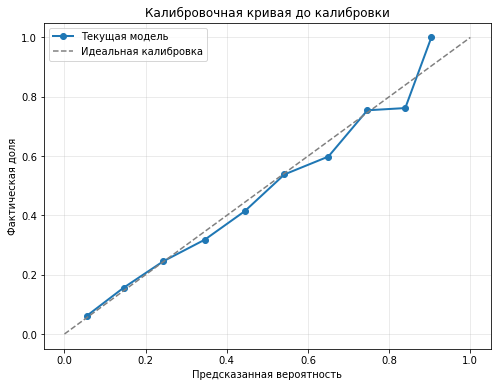

In [57]:
# Обучение финальной модели на данных обучения
final_pipeline.fit(X_train, y_train)

# Получаем предсказанные вероятности на тесте до калибровки
y_prob_before = final_pipeline.predict_proba(X_test)[:, 1]

# Строим калибровочную кривую
prob_true, prob_pred = calibration_curve(y_test, y_prob_before, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Текущая модель')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Идеальная калибровка')
plt.xlabel('Предсказанная вероятность')
plt.ylabel('Фактическая доля')
plt.title('Калибровочная кривая до калибровки')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

#### 9.2 Применение методов калибровки <a id='Применение-методов-калибровки'></a>

Для повышения качества вероятностных предсказаний моделей воспользуемся методом калибровки `CalibratedClassifierCV` с параметром `method='isotonic'`.

Для этого мы разделим уже имеющуюся обучающую выборку (X_train, y_train) на две части: для обучения модели и для её калибровки.

In [58]:
# Извлекаем компоненты из пайплайна
preprocessor = final_pipeline.named_steps['preprocessor']
base_classifier = final_pipeline.named_steps['classifier']

# Создаем и обучаем калибратор на калибровочной выборке
calibrator = CalibratedClassifierCV(
    base_estimator=base_classifier,
    method='isotonic',
    cv='prefit'
)

# Обучаем калибратор
X_calib_processed = preprocessor.transform(X_calib)
calibrator.fit(X_calib_processed, y_calib)

CalibratedClassifierCV(base_estimator=LogisticRegression(C=1, max_iter=1000,
                                                         random_state=42),
                       cv='prefit', method='isotonic')

#### 9.3 Сравнение моделей до и после калибровки <a id='Сравнение-моделей-до-и-после-калибровки'></a>

In [59]:
# Получаем вероятности после калибровки для теста
X_test_processed = preprocessor.transform(X_test)
y_prob_after = calibrator.predict_proba(X_test_processed)[:, 1]

# Рассчитываем метрики для модели ДО калибровки
brier_before = brier_score_loss(y_test, y_prob_before)
pr_auc_before = average_precision_score(y_test, y_prob_before)
roc_auc_before = roc_auc_score(y_test, y_prob_before)
logloss_before = log_loss(y_test, y_prob_before)

# Рассчитываем метрики для модели ПОСЛЕ калибровки
brier_after = brier_score_loss(y_test, y_prob_after)
pr_auc_after = average_precision_score(y_test, y_prob_after)
roc_auc_after = roc_auc_score(y_test, y_prob_after)
logloss_after = log_loss(y_test, y_prob_after)

# Метрики классификации (с порогом 0.5)
y_pred_before = (y_prob_before >= 0.5).astype(int)
y_pred_after = (y_prob_after >= 0.5).astype(int)

pre_before = precision_score(y_test, y_pred_before, average='binary')
recall_before = recall_score(y_test, y_pred_before, average='binary')
f1_before = f1_score(y_test, y_pred_before, average='binary')

pre_after = precision_score(y_test, y_pred_after, average='binary')
recall_after = recall_score(y_test, y_pred_after, average='binary')
f1_after = f1_score(y_test, y_pred_after, average='binary')

# Собираем все результаты в таблицу
metrics_df = pd.DataFrame({
    'Метрика': ['Brier Score', 'PR-AUC', 'ROC-AUC', 'Log Loss', 
                'Precision', 'Recall', 'F1-Score'],
    'До калибровки': [f"{brier_before:.4f}", f"{pr_auc_before:.4f}", f"{roc_auc_before:.4f}", 
           f"{logloss_before:.4f}", f"{pre_before:.4f}", f"{recall_before:.4f}", f"{f1_before:.4f}"],
    'После калибровки': [f"{brier_after:.4f}", f"{pr_auc_after:.4f}", f"{roc_auc_after:.4f}", 
              f"{logloss_after:.4f}", f"{pre_after:.4f}", f"{recall_after:.4f}", f"{f1_after:.4f}"]
})

print('\n=== ИТОГОВОЕ СРАВНЕНИЕ МЕТРИК ДО и ПОСЛЕ КАЛИБРОВКИ ===\n')
print(metrics_df.to_string(index=False))
print()


=== ИТОГОВОЕ СРАВНЕНИЕ МЕТРИК ДО и ПОСЛЕ КАЛИБРОВКИ ===

    Метрика До калибровки После калибровки
Brier Score        0.1250           0.1253
     PR-AUC        0.3984           0.3837
    ROC-AUC        0.7438           0.7433
   Log Loss        0.4021           0.4124
  Precision        0.5985           0.5775
     Recall        0.1412           0.1580
   F1-Score        0.2285           0.2482



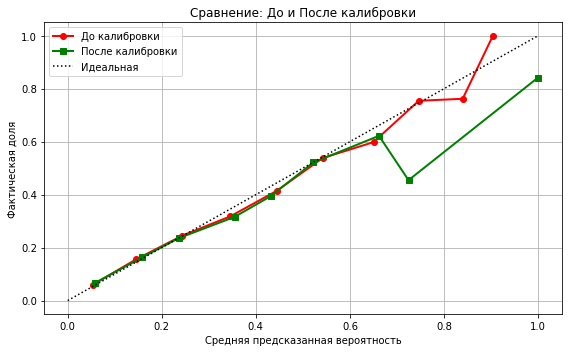

In [60]:
# Визуализация
plt.figure(figsize=(8, 5))

# Кривая ДО
prob_true_before, prob_pred_before = calibration_curve(y_test, y_prob_before, n_bins=10)
plt.plot(prob_pred_before, prob_true_before, 
         marker='o', label='До калибровки', color='red', linewidth=2)

# Кривая ПОСЛЕ
prob_true_after, prob_pred_after = calibration_curve(y_test, y_prob_after, n_bins=10)
plt.plot(prob_pred_after, prob_true_after,
         marker='s', label='После калибровки', color='green', linewidth=2)

plt.plot([0, 1], [0, 1], "k:", label="Идеальная")
plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Фактическая доля")
plt.title("Сравнение: До и После калибровки")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 10. Оценка качества калибровки <a id='Оценка-качества-калибровки'></a>

#### 10.1 Метрики калибровки <a id='Метрики-калибровки'></a>

In [61]:
def calculate_calibration_errors(y_true, y_prob, n_bins=10):
    """
    Рассчитывает Expected Calibration Error (ECE) и Maximum Calibration Error (MCE).
    
    Возвращает:
        tuple: (ECE, MCE)
    """
    bins = np.linspace(0, 1, n_bins + 1)
    
    # Инициализируем переменные для обоих метрик
    ece = 0.0
    max_error = 0.0
    n = len(y_true)
    
    for i in range(n_bins):
        bin_lower, bin_upper = bins[i], bins[i + 1]
        
        # Обрабатываем границы последнего интервала
        if i == n_bins - 1:
            mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
        else:
            mask = (y_prob >= bin_lower) & (y_prob < bin_upper)
        
        # Проверяем, есть ли объекты в текущем интервале
        if np.sum(mask) > 0:
            bin_confidence = np.mean(y_prob[mask])
            bin_accuracy = np.mean(y_true[mask])
            
            # Расчет ошибки для текущего интервала
            error = np.abs(bin_confidence - bin_accuracy)
            
            # Накопление для ECE
            ece += error * np.sum(mask)
            
            # Поиск максимума для MCE
            max_error = max(max_error, error)
    
    # Возвращаем финальные значения
    return (ece / n, max_error)

ece_before, mce_before = calculate_calibration_errors(y_test, y_prob_before)
ece_after, mce_after = calculate_calibration_errors(y_test, y_prob_after)

# Создаем DataFrame для сравнения
comparison_df =  pd.DataFrame({
    'Метрика': ['ECE (Expected Calibration Error)', 'MCE (Maximum Calibration Error)'],
    'До калибровки': [f"{ece_before:.4f}", f"{mce_before:.4f}"],
    'После калибровки': [f"{ece_after:.4f}", f"{mce_after:.4f}"]
})

# Устанавливаем "Метрика" как индекс
comparison_df.set_index('Метрика', inplace=True)

# Выводим таблицу
print('\nСРАВНЕНИЕ МЕТРИК КАЛИБРОВКИ ДО и ПОСЛЕ КАЛИБРОВКИ:\n')
print(comparison_df.to_string())


СРАВНЕНИЕ МЕТРИК КАЛИБРОВКИ ДО и ПОСЛЕ КАЛИБРОВКИ:

                                 До калибровки После калибровки
Метрика                                                        
ECE (Expected Calibration Error)        0.0099           0.0110
MCE (Maximum Calibration Error)         0.0961           0.2700


#### 10.2 Сравнение моделей до и после калибровки <a id='Сравнение-моделей-до-и-после-калибровки-2'></a>

Для наглядного сравнения качества модели до и после калибровки все основные метрики сведем в единую таблицу. Такой подход позволяет быстро оценить, как изменились показатели и повлияла ли калибровка на предсказательную способность и надёжность модели.

In [62]:
# Создание единого словаря метрик
metrics_dict = {
    'Brier Score': (brier_before, brier_after),
    'PR-AUC': (pr_auc_before, pr_auc_after),
    'ROC-AUC': (roc_auc_before, roc_auc_after),
    'Log Loss': (logloss_before, logloss_after),
    'Precision (w)': (pre_before, pre_after),
    'Recall (w)': (recall_before, recall_after),
    'F1-Score (w)': (f1_before, f1_after),
    'ECE (Expected Calibration Error)': (ece_before, ece_after),
    'MCE (Maximum Calibration Error)': (mce_before, mce_after)
}

data = {
    'Метрика': list(metrics_dict.keys()),
    'До калибровки': [value[0] for value in metrics_dict.values()],
    'После калибровки': [value[1] for value in metrics_dict.values()]
}
combined_df = pd.DataFrame(data)

# Форматирование и вывод
display_df = combined_df.copy()

display_df['До калибровки'] = display_df['До калибровки'].map(lambda x: f"{x:.4f}")
display_df['После калибровки'] = display_df['После калибровки'].map(lambda x: f"{x:.4f}")

display_df.set_index('Метрика', inplace=True)

print("\n=== СРАВНЕНИЕ МЕТРИК ДО и ПОСЛЕ КАЛИБРОВКИ (сводная таблица) ===")
print(display_df.to_string())

# Вывод о результате
print("\n=== ВЫВОД О РЕЗУЛЬТАТЕ ===")
ece_values = metrics_dict['ECE (Expected Calibration Error)']
mce_values = metrics_dict['MCE (Maximum Calibration Error)']
brier_values = metrics_dict['Brier Score']
logloss_values = metrics_dict['Log Loss']

if ece_values[1] < ece_values[0] and mce_values[1] < mce_values[0]:
    print("✅ Калибровка прошла успешно: ECE и MCE уменьшились.")
else:
    print("⚠️ Калибровка не привела к ожидаемому снижению ошибок калибровки.")


=== СРАВНЕНИЕ МЕТРИК ДО и ПОСЛЕ КАЛИБРОВКИ (сводная таблица) ===
                                 До калибровки После калибровки
Метрика                                                        
Brier Score                             0.1250           0.1253
PR-AUC                                  0.3984           0.3837
ROC-AUC                                 0.7438           0.7433
Log Loss                                0.4021           0.4124
Precision (w)                           0.5985           0.5775
Recall (w)                              0.1412           0.1580
F1-Score (w)                            0.2285           0.2482
ECE (Expected Calibration Error)        0.0099           0.0110
MCE (Maximum Calibration Error)         0.0961           0.2700

=== ВЫВОД О РЕЗУЛЬТАТЕ ===
⚠️ Калибровка не привела к ожидаемому снижению ошибок калибровки.


## 11. Финальный отчёт и выводы <a id='Финальный-отчёт-и-выводы'></a>

### 11.1 Сравнительный анализ моделей и метрик <a id='Сравнительный-анализ-моделей-и-метрик'></a>

**1. Сравнение с базовой моделью (DummyClassifier)**

Для оценки практической значимости построенных моделей их результаты были сопоставлены с базовой моделью DummyClassifier. Эта модель предсказывает классы, не обучаясь на данных, и служит минимальной точкой отсчёта.

In [63]:
df.index = df.index.map(lambda name: 'Финальная модель' if name == 'LogisticRegression' else name)
models_to_show = ['DummyClassifier', 'Финальная модель']
table1 = df.loc[models_to_show]
print('Таблица 1. Сравнение моделей')
print(table1.to_string())

Таблица 1. Сравнение моделей
                  Accuracy  Precision  Recall  F1-score  ROC-AUC  PR-AUC
DummyClassifier     0.7181     0.1718  0.1671    0.1694   0.4999  0.1721
Финальная модель    0.8362     0.6068  0.1393    0.2263   0.7495  0.4058


Финальная модель значительно превосходит базовую по большинству метрик, особенно по Accuracy (+11.8%) и ROC-AUC (+0.25).<br>
Это подтверждает её способность к обучению. Модель эффективно разделяет классы, но при работе с редким классом («клик») демонстрирует компромисс: точность (Precision) выросла до 0.61, однако полнота (Recall) осталась низкой — 0.14.

**2. Характеристики финальной модели на тестовой выборке**

Оценка качества финальной модели проводилась на тестовой выборке, которая не участвовала в обучении.

Модель является эффективной и обучаемой. Она успешно решает задачу ранжирования (ROC-AUC 0.75) и значительно повышает надёжность предсказаний клика (Precision). Снижение полноты (Recall) является приемлемой платой за такой рост точности.

**3. Влияние калибровки на финальную модель**

Для улучшения достоверности предсказанных вероятностей была проведена калибровка.

In [64]:
table2 = display_df
print('Таблица 2. Сравнение метрик до и после калибровки')
print(table2.to_string())

Таблица 2. Сравнение метрик до и после калибровки
                                 До калибровки После калибровки
Метрика                                                        
Brier Score                             0.1250           0.1253
PR-AUC                                  0.3984           0.3837
ROC-AUC                                 0.7438           0.7433
Log Loss                                0.4021           0.4124
Precision (w)                           0.5985           0.5775
Recall (w)                              0.1412           0.1580
F1-Score (w)                            0.2285           0.2482
ECE (Expected Calibration Error)        0.0099           0.0110
MCE (Maximum Calibration Error)         0.0961           0.2700


Калибровка не привела к улучшению качества модели по ключевым метрикам. Ошибки калибровки (ECE, MCE) также увеличились, что говорит о неэффективности применённого метода для данной модели и данных.

**4. Интерпретация модели (топ-5 важных признаков)**

Анализ коэффициентов логистической регрессии позволил определить наиболее влиятельные признаки для принятия решения.

Наибольшее влияние на предсказание оказывают признаки `feature_16`(8.56) и `feature_15`(5.66). Их высокие коэффициенты свидетельствуют о сильной связи с целевой переменной.

### 11.2 Ключевые выводы <a id='Ключевые-выводы'></a>

Построенная модель значительно превосходит базовый уровень. По сравнению с DummyClassifier, который предсказывает классы случайным образом, финальная модель демонстрирует рост Accuracy на 11.8% (с 71.8% до 83.6%) и рост способности к ранжированию (ROC-AUC) на 0.25 (с 0.5 до 0.75). Это подтверждает, что модель успешно обучилась и способна извлекать полезные закономерности из данных.

Наибольшее влияние на целевую переменную оказывают признаки `feature_16` и `feature_15`. Их коэффициенты (8.56 и 5.66 соответственно) значительно превышают веса других признаков, что говорит об их доминирующей роли в принятии решения моделью.

## 12. Сохранение модели для продакшена <a id='Сохранение-модели-для-продакшена'></a>

### 12.1 Сохранение артефактов <a id='Сохранение-артефактов'></a>

In [66]:
# Создаем финальный пайплайн, который уже обучен и откалиброван
final_calibrated_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', calibrator)
])

# Сохраняем основной пайплайн
joblib.dump(final_calibrated_pipeline, 'click_final_calibrated_model.joblib')
print("✅ Финальный откалиброванный пайплайн сохранен в файл 'click_final_calibrated_model.joblib'.")

# Сохраняем информацию об отборе признаков
try:
    joblib.dump(rfe, 'selected_features_indices.joblib')
    print("✅ Информация об отобранных признаках сохранена в файл 'selected_features_indices.joblib'.")
except NameError:
    print("⚠️ Отбор признаков RFE не выполнялся или переменная rfe не существует.")

✅ Финальный откалиброванный пайплайн сохранен в файл 'click_final_calibrated_model.joblib'.
✅ Информация об отобранных признаках сохранена в файл 'selected_features_indices.joblib'.


### 12.2 Проверка работоспособности кода <a id='Проверка-работоспособности-кода'></a>

In [67]:
print("\nПРОВЕРКА СОХРАНЕНИЯ И ЗАГРУЗКИ ПАЙПЛАЙНА:")

try:
    loaded_full_pipeline = joblib.load('click_final_calibrated_model.joblib')
    print("📥 Загружен полный пайплайн из 'click_final_calibrated_model.joblib'")
except FileNotFoundError:
    print("❌ Ошибка: Файл 'click_final_calibrated_model.joblib' не найден.")
    loaded_full_pipeline = None

# Проверяем, удалось ли нам загрузить объект
if loaded_full_pipeline is not None:
    test_passed = True

    np.random.seed(RANDOM_STATE)
    
    # Выбираем 5 уникальных случайных индексов из тестовой выборки
    test_sample_indices = np.random.choice(len(X_test), 5, replace=False)

    # Проходим по каждому из 5 выбранных индексов
    for idx in test_sample_indices:
        sample = X_test.iloc[[idx]]

        old_prob = final_calibrated_pipeline.predict_proba(sample)[0, 1]
        new_prob = loaded_full_pipeline.predict_proba(sample)[0, 1]
        
        if not np.isclose(new_prob, old_prob, atol=1e-5):
            print(f"❌ Несовпадение для индекса {idx}:")
            print(f"   Из файла: {new_prob:.6f}")
            print(f"   Из памяти: {old_prob:.6f}")
            test_passed = False

    # Вывод итогового результата
    print("\nРЕЗУЛЬТАТ ПРОВЕРКИ РАБОТОСПОСОБНОСТИ НА ПЯТИ НОВЫХ ТЕСТОВЫХ СЛУЧАЯХ:")

    if test_passed:
        print("✅ Предсказания совпадают. Код для продакшена работает корректно.")
    else:
        print("❌ Предсказания не совпадают. В логике сохранения или загрузки данных есть ошибка.")


ПРОВЕРКА СОХРАНЕНИЯ И ЗАГРУЗКИ ПАЙПЛАЙНА:
📥 Загружен полный пайплайн из 'click_final_calibrated_model.joblib'

РЕЗУЛЬТАТ ПРОВЕРКИ РАБОТОСПОСОБНОСТИ НА ПЯТИ НОВЫХ ТЕСТОВЫХ СЛУЧАЯХ:
✅ Предсказания совпадают. Код для продакшена работает корректно.
